# 损失、优化与评估

## 【章节目标】
- 知道tensorflow中的常用损失函数
- 掌握常用损失函数的使用方法
- 掌握自定义损失函数的方法
- 掌握tensorflow优化器使用方法
- 知道tensorflow常用评估方法
- 掌握常用评估方法的使用方法
- 掌握自定义评估函数的方法

## 【章节内容】
### 损失函数
tensorflow中损失函数实现都位于tf.keras.losses模块中，实现形式有两种：

- 函数，例如：mean_squared_error
- 类，例如：MeanSquaredError

常用损失函数

- mean_squared_error、MSE（平方差误差损失，用于回归，简写为 mse, 类实现形式为MeanSquaredError）
- binary_crossentropy(二元交叉熵，用于二分类，类实现形式为 BinaryCrossentropy)
- categorical_crossentropy(类别交叉熵，用于多分类，要求label为onehot编码，类实现形式为CategoricalCrossentropy)
- sparse_categorical_crossentropy(稀疏类别交叉熵，用于多分类，要求label为序号编码形式，类实现形式为SparseCategoricalCrossentropy)

更多参考：https://www.tensorflow.org/api_docs/python/tf/keras/losses

#### 1）均方差损失MSE

- 函数：tf.keras.losses.mean_squared_error、tf.keras.losses.MSE
- 类：tf.keras.losses.MeanSquaredError

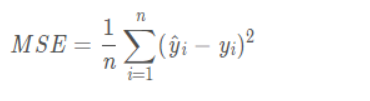

参数：

- y_true：真实值，shape：(b,1)
- y_pred：预测值，shape：(b,1)

In [4]:
import tensorflow as tf

y_true = tf.constant([1, 2, 3, 0, 2], dtype = tf.float32)

y_pred = tf.random.normal([5])

loss1 = tf.reduce_mean(tf.square(y_true - y_pred)) # 手动计算

# 函数
loss2 = tf.keras.losses.mean_squared_error(y_true, y_pred) # 函数形式损失计算
loss3 = tf.keras.losses.MSE(y_true, y_pred) # 简写函数形式损失计算

# 类
loss_func = tf.keras.losses.MeanSquaredError() # 类形式，先定义对象
loss4 = loss_func(y_true, y_pred) # 调用对象方法

print(loss1)
print(loss2)
print(loss3)
print(loss4)

tf.Tensor(3.6097527, shape=(), dtype=float32)
tf.Tensor(3.6097527, shape=(), dtype=float32)
tf.Tensor(3.6097527, shape=(), dtype=float32)
tf.Tensor(3.6097527, shape=(), dtype=float32)


#### 2）二元交叉熵
- 函数：binary_crossentropy
- 类：BinaryCrossentropy

二分类交叉熵损失函数：
$$\large L=\frac{1}{N}\sum_i{L_i}=-\frac{1}{N}\sum_i{y_i\times \log{p_i}+(1-y_i)\times \log{(1-p_i)}}$$

对应的是网络输出单个节点，这个节点将被sigmoid处理，使用阈值分类为0或者1的问题。

**参数：**

- y_true：真实值，shape：(b,1)
- y_pred：预测值，shape：(b,1)
- from_logits:bool值，表示y_pred是否需要进行sigmoid计算，默认为False，表示y_pred本身已经经过sigmoid概率计算
    - True:不需要提前将概率计算好
    - False：需要提前将概率计算好

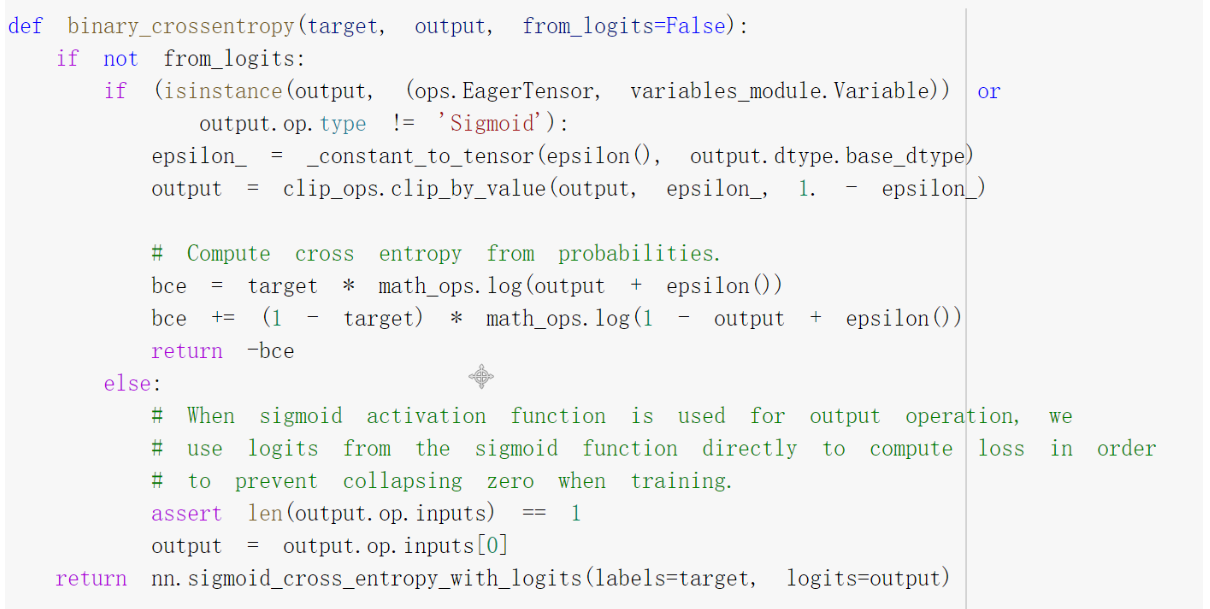

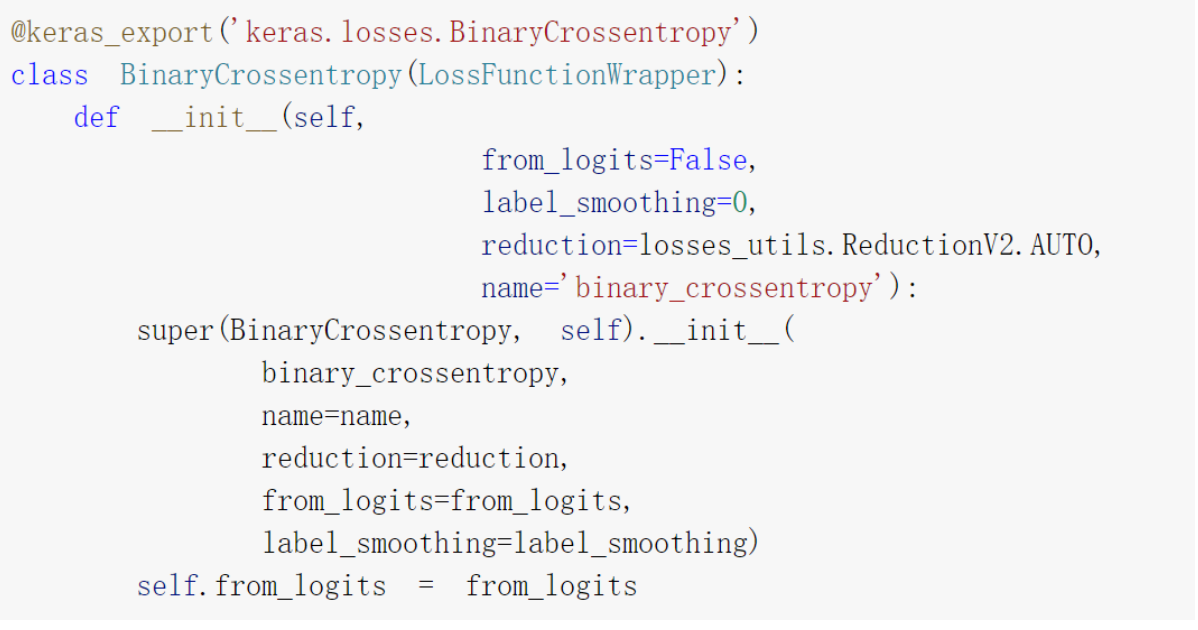

In [2]:
y_true = tf.constant([1, 0, 1, 0, 1], dtype = tf.float32)

logits = tf.random.normal([5])
y_pred = tf.nn.sigmoid(logits) # 提前将概率计算好

loss1 = -tf.reduce_mean(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred)) # 手动计算

# 函数
loss2 = tf.keras.losses.binary_crossentropy(y_true, y_pred) # y_pred为概率 from_logits=False
loss3 = tf.keras.losses.binary_crossentropy(y_true, logits, from_logits = True) # Logits 需要经过sigmoid计算概率

# 类实现
loss_func = tf.keras.losses.BinaryCrossentropy()
loss4 = loss_func(y_true, y_pred) # 调用对象方法

print(loss1)
print(loss2)
print(loss3)
print(loss4)

tf.Tensor(0.8072995, shape=(), dtype=float32)
tf.Tensor(0.8072993, shape=(), dtype=float32)
tf.Tensor(0.8072996, shape=(), dtype=float32)
tf.Tensor(0.8072993, shape=(), dtype=float32)


#### 3）交叉熵损失函数
- 函数：categorical_crossentropy、sparse_categorical_crossentropy ***每个样本返回一个值，还需要求平均***
- 类：CategoricalCrossentropy、SparseCategoricalCrossentropy 直接返回平均值

多分类交叉熵损失函数：

$$\large L=\frac{1}{N}\sum_i{L_i}=-\frac{1}{N}\sum_i{\sum_{c=1}^K{y_{ic}\times \log{p_{ic}}}}$$

其中：

- N — 样本的数量；
- K — 类别的数量，K类求和中只有一个是非零；
- yic — 指示变量（0或1）,如果该类别和样本 i的类别相同就是1，否则是0；
- Pic — 对于观测样本i属于类别 c 的预测概率。

**categorical_crossentropy和sparse_categorical_crossentropy区别：y_true形式不一样**

- categorical_crossentropy：
    - y_pred：(b,c)
    - y_true：(b,c)为onehot向量
- sparse_categorical_crossentropy：
    - y_pred：(b,c)
    - y_true：(b,1)为类别下标向量

In [3]:
y_true=tf.convert_to_tensor([1, 2])#(b,)
logits=tf.random.normal([2,3])#(b,c)  网络输出值
y_pred=tf.nn.softmax(logits)#计算概率
y_true_onehot=tf.one_hot(y_true,3)#  做onehot类别数3 (b,3)
print(y_true_onehot)
losses=[]

losses.append(-tf.reduce_mean(tf.reduce_sum(y_true_onehot * tf.math.log(y_pred), axis = -1))) # 手动计算

#函数
losses.append(tf.keras.losses.categorical_crossentropy(y_true_onehot, y_pred))#y_true_onehot为oenhot向量
losses.append(tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred))#y_true为样本真是类别下标
losses.append(tf.keras.losses.categorical_crossentropy(y_true_onehot, logits,from_logits=True))#logits需要经过softmax计算概率
losses.append(tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_true, logits,from_logits=True)))
# #类
loss_func1=tf.keras.losses.CategoricalCrossentropy()#类形式，先定义对象
loss_func2=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)#类形式，先定义对象
losses.append(loss_func1(y_true_onehot, y_pred)) # 调用对象方法进行损失计算
losses.append(loss_func2(y_true, logits)) # 调用对象方法进行损失计算

for loss in losses:
    print(loss) 

tf.Tensor(
[[0. 1. 0.]
 [0. 0. 1.]], shape=(2, 3), dtype=float32)
tf.Tensor(1.4528503, shape=(), dtype=float32)
tf.Tensor([1.2941236 1.6115769], shape=(2,), dtype=float32)
tf.Tensor([1.2941236 1.611577 ], shape=(2,), dtype=float32)
tf.Tensor([1.2941236 1.6115768], shape=(2,), dtype=float32)
tf.Tensor(1.4528502, shape=(), dtype=float32)
tf.Tensor(1.4528503, shape=(), dtype=float32)
tf.Tensor(1.4528502, shape=(), dtype=float32)


#### 4）自定义损失函数
两种方法自定义函数：

- 函数的实现形式
- 类的实现形式：自定义损失函数需要继承 tf.keras.losses.Loss 类，重写 call 方法即可，输入真实值 y_true 和模型预测值 y_pred ，输出模型预测值和真实值之间通过自定义的损失函数计算出的损失值。

下面的示例为均方差损失函数：

In [5]:
# 类
class MeanSquaredError(tf.keras.losses.Loss):
    def call(self, y_true, y_pred):
        return tf.reduce_mean(tf.square(y_true - y_pred)) # 实现损失计算的过程
    
# 函数式
def mean_squared_error(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_pred - y_true))

#### 5）Focal loss损失函数实现
原始论文的Focal loss损失函数针对于二分类，这里改为多分类损失函数：

$$\large FL(p_t)=-\sum_{c=1}^K{\alpha_k\times (1-p_t)^\gamma \times y_c \times\ log(p_t)}$$

其中，

- K表示类别数
- yc是真实标签
- Pt是预测概率
- γ是调节因子
- αk是第k类的权重

**Focal loss损失函数代码实现**

In [6]:
# 多分类的focal loss 损失函数
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alphas=None, class_num=10):
        super(SparseFocalLoss, self).__init__()
        self.gamma = tf.constant(gamma,dtype=tf.float32)
        if alphas is None:
            self.alphas = tf.constant([1.0 for i in range(class_num)])#一定要是constant  不能是variable
        else:
            self.alphas=tf.constant(alphas)#alphas必须是常量，这样不会被求导更新，损失才能下降
        self.class_num = class_num

    @tf.function
    def call(self, y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        prob = tf.clip_by_value(y_pred, epsilon, 1.0)
        #labels_index = tf.stack([tf.range(y_true.shape[0]), y_true], axis=1) 这里是获取静态的batch_size ⬇改进使用动态写法提升鲁棒性
        labels_index = tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1) #构建真实类别下标
        print(labels_index)
        prob = tf.gather_nd(prob, labels_index) # 获取真实类别对应的预测概率
        alpha_choice = tf.gather(self.alphas, y_true) # 获取类别权重α
        weight = tf.pow(tf.subtract(1., prob), self.gamma) # focal权重
        weight = tf.multiply(alpha_choice, weight) # 权重相乘

        loss = -tf.reduce_mean(tf.multiply(weight, tf.math.log(prob)))
        return loss
    

y_true=tf.convert_to_tensor([1, 2])#(b,)
logits=tf.random.normal([2,3])#(b,c)
y_pred=tf.nn.softmax(logits)

loss_func1=SparseFocalLoss(gamma=2,class_num=3)
loss_func2=tf.keras.losses.SparseCategoricalCrossentropy()#类形式，先定义对象
print(loss_func1(y_true, y_pred)) # 调用对象方法进行损失计算
print(loss_func2(y_true, y_pred)) # 调用对象方法进行损失计算        

Tensor("stack:0", shape=(2, 2), dtype=int32)
tf.Tensor(0.91746515, shape=(), dtype=float32)
tf.Tensor(1.4013014, shape=(), dtype=float32)


### 优化器
#### 1）优化器的使用
- 1.自定义训练：优化器主要使用apply_gradients方法传入变量和对应梯度从而来对给定变量进行迭代,或者直接使用minimize方法对目标函数进行迭代优化(可读性差一点，不推荐用)。

    - optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    - optimizer.minimize(f,[x])

- 2.keras训练方式：在编译时将优化器传入keras的Model,通过调用model.fit实现对Loss的的迭代优化。

**定义打印时间分割线**

In [7]:
import tensorflow as tf
import numpy as np 
 
# 打印时间分割线
@tf.function
def printbar():
    ts = tf.timestamp()
    today_ts = ts%(24*60*60)
    hour = tf.cast(today_ts//3600+8,tf.int32)%tf.constant(24)
    minite = tf.cast((today_ts%3600)//60,tf.int32)
    second = tf.cast(tf.floor(today_ts%60),tf.int32)
    
    def timeformat(m):
        if tf.strings.length(tf.strings.format("{}",m))==1:
            return(tf.strings.format("0{}",m))
        else:
            return(tf.strings.format("{}",m))
    
    timestring = tf.strings.join([timeformat(hour),timeformat(minite),
                timeformat(second)],separator = ":")
    tf.print("=========="*8,end = "")
    tf.print(timestring)

optimizer.apply_gradients

In [10]:
# 求f(x) = a*x**2 + b*x + c的最小值
 
# 使用optimizer.apply_gradients
 
x = tf.Variable(0.0,name = "x",dtype = tf.float32)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
 
@tf.function
def minimizef():
    a = tf.constant(1.0)
    b = tf.constant(-2.0)
    c = tf.constant(1.0)

    while tf.constant(True):
        with tf.GradientTape() as tape:
            y = a * tf.pow(x, 2) + b * x + c
        dy_dx = tape.gradient(y, x)
        optimizer.apply_gradients(grads_and_vars = [(dy_dx, x)]) # 优化器更新参数

        #迭代终止条件
        if tf.abs(dy_dx)<tf.constant(0.00001):
            break

        if tf.math.mod(optimizer.iterations,100)==0:
            printbar()
            tf.print("step = ",optimizer.iterations)
            tf.print("x = ", x)
            tf.print("")

    y = a*tf.pow(x,2) + b*x + c
    return y
 
tf.print("y =",minimizef())
tf.print("x =",x)

================================================================================15:28:18
step =  100
x =  0.867380381

================================================================================15:28:18
step =  200
x =  0.98241204

================================================================================15:28:18
step =  300
x =  0.997667611

================================================================================15:28:19
step =  400
x =  0.999690711

================================================================================15:28:19
step =  500
x =  0.999959

================================================================================15:28:19
step =  600
x =  0.999994516

y = 0
x = 0.999995232


optimizer.minimize

In [11]:
# 求f(x) = a*x**2 + b*x + c的最小值
 
# 使用optimizer.minimize
 
x = tf.Variable(0.0,name = "x",dtype = tf.float32)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)   
 
def f():   
    a = tf.constant(1.0)
    b = tf.constant(-2.0)
    c = tf.constant(1.0)
    y = a*tf.pow(x,2)+b*x+c
    return(y)
 
@tf.function
def train(epoch = 1000):  
    for _ in tf.range(epoch):  
        optimizer.minimize(f,[x])#内部隐含了求导
    tf.print("epoch = ",optimizer.iterations)
    return(f())
 
train(1000)
tf.print("y = ",f())
tf.print("x = ",x)

epoch =  1000
y =  0
x =  0.999998569


使用model.fit

In [12]:
# 求f(x) = a*x**2 + b*x + c的最小值
# 使用model.fit
 
tf.keras.backend.clear_session()
 
class FakeModel(tf.keras.models.Model):
    def __init__(self,a,b,c):
        super(FakeModel,self).__init__()
        self.a = a
        self.b = b
        self.c = c

    def build(self):
        self.x = tf.Variable(0.0,name = "x")
        self.built = True

    def call(self,features):
        loss  = self.a*(self.x)**2+self.b*(self.x)+self.c
        return(tf.ones_like(features)*loss)

def myloss(y_true,y_pred):
    return tf.reduce_mean(y_pred)
 
model = FakeModel(tf.constant(1.0),tf.constant(-2.0),tf.constant(1.0))
 
model.build()
model.summary()
 
model.compile(optimizer = 
              tf.keras.optimizers.SGD(learning_rate=0.01),loss = myloss)
history = model.fit(tf.zeros((100,2)),
                    tf.ones(100),batch_size = 1,epochs = 10)  #迭代1000次
 
tf.print("x=",model.x)
tf.print("loss=",model(tf.constant(0.0)))

Model: "fake_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (4.00 Byte)
Trainable params: 1 (4.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
100/100 [==============================] - 1s 2ms/step - loss: 0.2481
Epoch 2/10
100/100 [==============================] - 0s 2ms/step - loss: 0.0044
Epoch 3/10
100/100 [==============================] - 0s 2ms/step - loss: 7.6740e-05
Epoch 4/10
100/100 [==============================] - 0s 2ms/step - loss: 1.3500e-06
Epoch 5/10
100/100 [==============================] - 0s 2ms/step - loss: 1.8477e-08
Epoch 6/10
100/100 [==============================] - 0s 2ms/step - loss: 0.0000e+00
Epoch 7/10
100/100 [==============================] - 0s 2ms/step - loss: 0.0000e+00
Epoch 8/10
100/100 [==============================] - 0s 2ms/step - loss: 0.0000e+00
Epoch 9/10
100

#### 2）内置优化器
深度学习优化算法大概经历了 SGD -> SGDM -> NAG ->Adagrad -> Adadelta(RMSprop) -> Adam -> Nadam 这样的发展历程。

在tf.keras.optimizers子模块中，它们基本上都有对应的类的实现。

- SGD：默认参数为纯SGD, 设置momentum参数不为0实际上变成SGDM, 考虑了一阶动量, 设置 nesterov为True后变成NAG，即 Nesterov Acceleration Gradient，在计算梯度时计算的是向前走一步所在位置的梯度。
- Adagrad：考虑了二阶动量，对于不同的参数有不同的学习率，即自适应学习率。缺点是学习率单调下降，可能后期学习速率过慢乃至提前停止学习。
- RMSprop：考虑了二阶动量，对于不同的参数有不同的学习率，即自适应学习率，对Adagrad进行了优化，通过指数平滑只考虑一定窗口内的二阶动量。
- Adadelta：考虑了二阶动量，与RMSprop类似，但是更加复杂一些，自适应性更强。
- Adam：同时考虑了一阶动量和二阶动量，可以看成RMSprop上进一步考虑了Momentum。
- Nadam,：在Adam基础上进一步考虑了 Nesterov Acceleration。

### 动态学习率
#### 1）学习率衰减方法

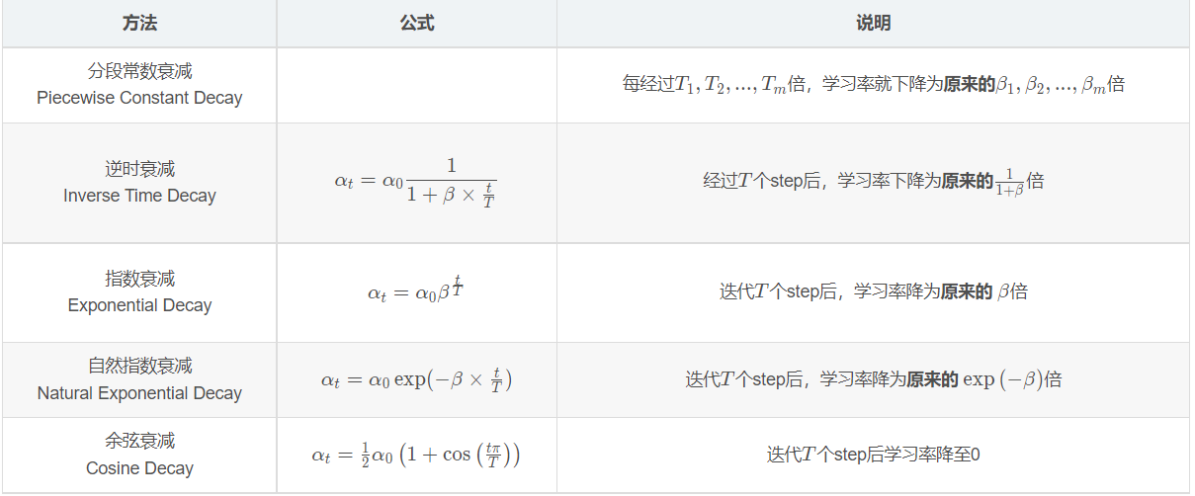

αt —— 第t tt个step时的学习率  
β —— 学习率衰减系数  
t —— 当前是第几个step  
T —— 经历个多少个step后完成一次学习率衰减

下图是不同学习率衰减的效果:  
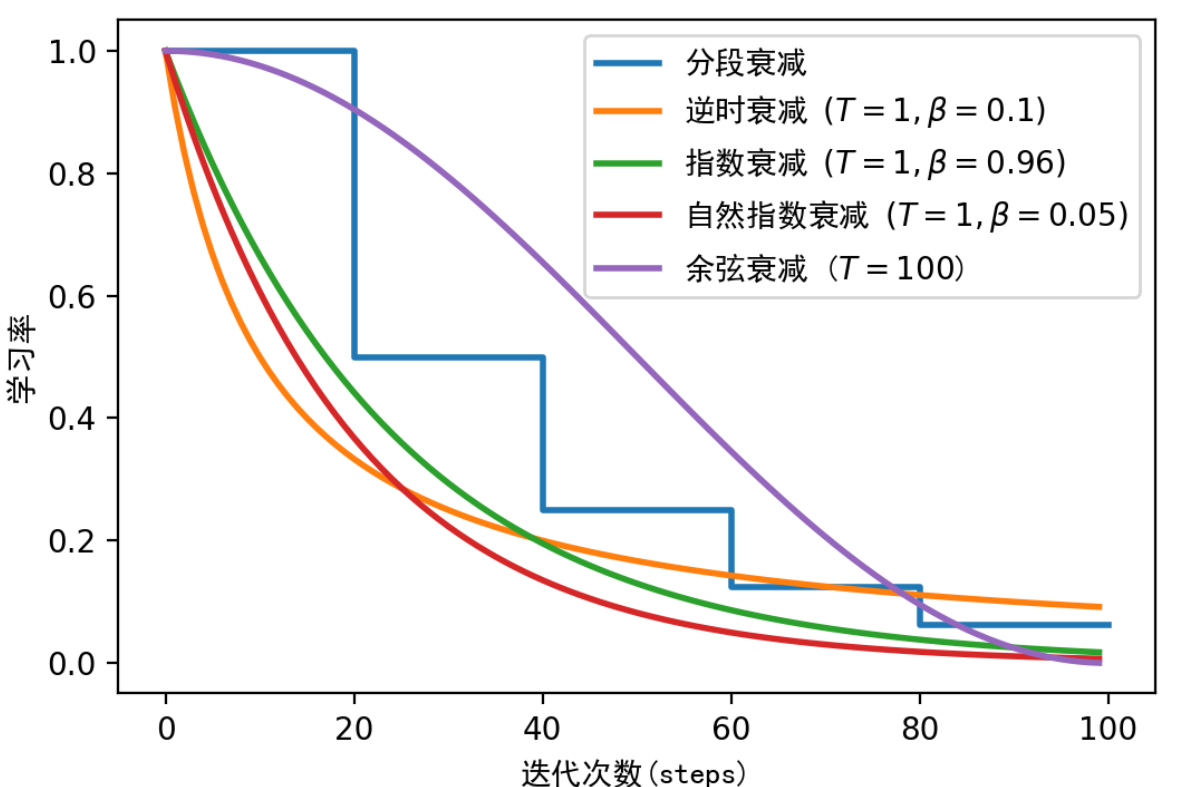

#### 2）TensorFlow2中的学习率衰减API
位于tf.keras.optimizers.schedules模块中

- 分段常数衰减：tf.keras.optimizers.schedules.PiecewiseConstantDecay(boundaries=boundaries, values=values, name=None)
- 逆时衰减：tf.keras.optimizers.schedules.InverseTimeDecay(initial_learning_rate=1., decay_steps=1, decay_rate=0.1)
- 指数衰减：tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=1., decay_steps=1, decay_rate=0.96)
- 余弦衰减：tf.keras.experimental.CosineDecay(initial_learning_rate=1., decay_steps=100)

#### 3）使用方法
学习率衰减调度器的使用方法非常简单，以指数衰减为例：

- 先创建一个学习率衰减调度器
- 把它传入你选择的优化器（这里选择Adam优化器）

In [13]:
# 1. 先创建指数衰减学习率
exponential_decay = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = 0.01, decay_steps = 1000, decay_rate = 0.96
)

# 2. 送入优化器
optimizer = tf.keras.optimizers.Adam(exponential_decay) # 不用再指定learning_rate
# 普通的优化器
# optimizer = tf.keras.optimizers.Adam(0.01)

#### 4）自定义实现学习率衰减
继承tf.keras.optimizers.schedules.LearningRateSchedule类，并重写__init__和__call__方法。

自定义**自然指数衰减(Natural Exponential Decay)**代码实现：

In [14]:
class NaturalExpDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_learning_rate, decay_steps, decay_rate):
        super().__init__()
        self.initial_learning_rate = tf.cast(initial_learning_rate, dtype=tf.float32)
        self.decay_steps = tf.cast(decay_steps, dtype=tf.float32)
        self.decay_rate = tf.cast(decay_rate, dtype=tf.float32)
        
    def __call__(self, step):
        #负责根据step计算当前的学习率
        return self.initial_learning_rate * tf.math.exp(-self.decay_rate * (step / self.decay_steps))
    
natural_exp_decay = NaturalExpDecay(initial_learning_rate=1, 
                                    decay_steps=1, 
                                    decay_rate=0.05)

### 模型评估指标
tensorflow中实现的模型评估指标位于tf.keras.metrics模块下，跟损失函数一样也是两种形式：

- 函数
- 类

使用方法跟损失函数类似，类更好用。

#### 1）常用回归评估函数
- tf.keras.metrics.MeanSquaredError （平方差误差，可以简写为MSE，函数形式为mse）
- tf.keras.metrics.MeanAbsoluteError (绝对值误差，可以简写为MAE，函数形式为mae)
- tf.keras.metrics.MeanAbsolutePercentageError (平均百分比误差，可以简写为MAPE，函数形式为mape)
- tf.keras.metrics.RootMeanSquaredError (均方根误差)

更多参考：https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras/metrics

#### 2）常用分类评估函数
- tf.keras.metrics.Accuracy (准确率，用于分类，可以用字符串"Accuracy"表示，Accuracy=(TP+TN)/(TP+TN+FP+FN)，要求y_true和y_pred都为类别序号编码)
- tf.keras.metrics.BinaryAccuracy ：针对二分类计算准确率。
- tf.keras.metrics.AUC (ROC曲线(TPR vs FPR)下的面积，用于二分类，直观解释为随机抽取一个正样本和一个负样本，正样本的预测值大于负样本的概率)
- tf.keras.metrics.Precision (精确率，用于二分类，Precision = TP/(TP+FP))
- tf.keras.metrics.Recall (召回率，用于二分类，Recall = TP/(TP+FN))
- tf.keras.metrics.TopKCategoricalAccuracy(多分类TopK准确率，要求y_true(label)为onehot编码形式)
- tf.keras.metrics.CategoricalAccuracy（分类准确率，与Accuracy含义相同，要求y_true(label)为onehot编码形式）
- tf.keras.metrics.SparseCategoricalAccuracy (稀疏分类准确率，与Accuracy含义相同，要求y_true(label)为序号编码形式)

更多参考：https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras/metrics

**最后二者的区别：**

In [26]:
#SparseCategoricalAccuracy
y_true = tf.constant([0,1,2,1,4,5,3])
y_pred = tf.random.uniform(shape=(7,6))
acc = tf.keras.metrics.SparseCategoricalAccuracy()
acc.update_state(y_true, y_pred) # y_true为序号(b,)，y_pred为(b,c)
tf.print(acc.result().numpy())
acc.reset_states()

0.2857143


In [27]:
#CategoricalAccuracy
y_true = tf.constant([0,1,2,1,4,5,3])
y_pred = tf.random.uniform(shape=(7,6))
y_true = tf.one_hot(y_true,depth=6,dtype=tf.int32)#y_true需要onehot
acc = tf.keras.metrics.CategoricalAccuracy()
acc.update_state(y_true,y_pred)#y_true为序号(b,c)，y_pred为(b,c)
tf.print(acc.result().numpy())
acc.reset_states()

0.0


#### 3）自定义评估函数
两种实现形式：基于类的实现和基于函数的实现

自定义评估指标需要继承 tf.keras.metrics.Metric 类，并重写 __init__ 、update_state 和 result 三个方法。

- __init__():所有状态变量都应通过以下方法在此方法中创建self.add_weight()
- update_state(): 对状态变量进行所有更新
- result(): 根据状态变量计算并返回指标值。

**自定义实现tf.keras.metrics.SparseCategoricalAccuracy()**

In [28]:
class SparseCategoricalAccuracy_(tf.keras.metrics.Metric):
    def __init__(self, name = 'SparseCategoricalAccuracy', **kwargs):
        super(SparseCategoricalAccuracy_, self).__init__(name = name, **kwargs)
        self.total = self.add_weight(name = 'total', dtype = tf.int32, initializer = tf.zeros_initializer())
        self.count = self.add_weight(name = 'count', dtype = tf.int32, initializer = tf.zeros_initializer())
    
    def update_state(self, y_true, y_pred, sample_weight = None):
        values = tf.cast(tf.equal(y_true, tf.argmax(y_pred, axis = -1, output_type = tf.int32)), tf.int32)
        self.total.assign_add(tf.shape(y_true)[0])
        self.count.assign_add(tf.reduce_sum(values))

    def result(self):
        return self.count / self.total
    
    def reset_state(self):
        # The state of the metric will be reset at the start of each epoch.
        self.total.assign(0) #总数归零
        self.count.assign(0) #正确个数归零

#### 4）使用方法
- 每个epoch开始时要reset_states()，归零total和count

- 一个epoch中的每次迭代中update_state()，累计总数total和正确样本个数count

- 每个epoch结束时执行result()得出结果

注意：以下代码不需要运行，仅作为自定义模型评估函数使用方法效果演示

In [ ]:
acc=SparseCategoricalAccuracy_()

for epoch in range(epochs):
    acc.reset_states()#归零
    for x,y in train_db:
        y_pred=model(x)
        loss=loss_func(y_pred,y)
        acc.update_state(y,y_pred)
    print(acc.result())

### FocalLoss实战花朵分类
#### 1）构建数据集

In [32]:
import tensorflow as tf
import random
import pathlib
data_path = pathlib.Path('Dataset/flower_photos/')
all_image_paths = list(data_path.glob('*/*'))
all_image_paths = [str(path) for path in all_image_paths] # 所有图片路径的列表
random.shuffle(all_image_paths)
label_names = sorted(item.name for item in data_path.glob('*/') if item.is_dir()) # 加载标签
label_to_index = dict((name, index) for index, name in enumerate(label_names)) # 构建标签字典
all_image_labels = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths] # 标签id化

# 分割数据集
total_num = len(all_image_paths)
split_index = int(0.8*total_num)
train_x, train_y = all_image_paths[:split_index], all_image_labels[:split_index]
val_x, val_y = all_image_paths[split_index:], all_image_labels[split_index:]

# 构建数据集
train_db = tf.data.Dataset.from_tensor_slices((train_x, train_y))
val_db = tf.data.Dataset.from_tensor_slices((val_x, val_y))

# 定义预处理方法
def load_and_preprocess_from_path_label(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [150, 150])  # 原始图片大小为(266, 320, 3)，重设为(150, 150)
    image /= 255.0  # 归一化到[0,1]范围
    return image, label
train_db  = train_db.map(load_and_preprocess_from_path_label)
val_db  = val_db.map(load_and_preprocess_from_path_label)

#打乱并分批次
BATCH_SIZE = 32
train_db = train_db.shuffle(1000).batch(BATCH_SIZE).cache().prefetch(1000)
val_db = val_db.batch(BATCH_SIZE).cache().prefetch(1000)

#### 2）搭建模型

In [33]:
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes,activation='softmax')
])
model.build(input_shape=(None, 150,150,3))#初始化模型参数
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 32)        9248      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 17, 17, 32)        0

#### 3）定义损失函数和优化器

In [34]:
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alphas=None, class_num=10):
        self.gamma = gamma
        if alphas is None:
            self.alphas = tf.constant([1.0 for i in range(class_num)])
        else:
            self.alphas=tf.constant(alphas)#alphas必须时常量，这样不会被求导更新，损失才能下降
        self.class_num = class_num
        super(SparseFocalLoss, self).__init__()
    @tf.function
    def call(self, y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        prob = tf.clip_by_value(y_pred, epsilon, 1.0)
        labels_index=tf.stack([tf.range(y_true.shape[0]),y_true],axis=1)#构建真实类别下标
        prob = tf.gather_nd(prob, labels_index)#获取真实类别对应的预测概率
        alpha_choice=tf.gather(self.alphas,y_true)#获取类别权重
        weight = tf.pow(tf.subtract(1., prob), self.gamma)#focal权重
        weight = tf.multiply(alpha_choice, weight)#权重相乘

        loss = -tf.reduce_mean(tf.multiply(weight, tf.math.log(prob)))
        return loss
#1.定义损失函数    
loss_func=SparseFocalLoss(gamma=2.0,alphas=[0.22,0.17,0.22,0.22,0.17],class_num=5)

# 2. 先创建指数衰减学习率
exponential_decay = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4, 
    decay_steps=200, 
    decay_rate=0.99)
# 3. 送入优化器
optimizer = tf.keras.optimizers.Adam(exponential_decay)

#4.定义评估函数
acc=tf.keras.metrics.SparseCategoricalAccuracy()

#### 4）训练

In [35]:
# @tf.function
def train(model,loss_func,optimizer,train_data,val_data,epochs=10):
    #训练  遍历epochs
    for  epoch in range(1,epochs+1):
        print('-'*10+f"epoch{epoch}"+'-'*10)
        #遍历数据集进行训练
        train_loss=0
        acc.reset_states()
        for step, (x_batch_train, y_batch_train) in enumerate(train_data):
            # 开一个gradient tape, 计算梯度
            with tf.GradientTape() as tape:
                predictions = model(x_batch_train)#计算输出值
                loss = loss_func(y_batch_train, predictions)#计算损失值
                gradients = tape.gradient(loss, model.trainable_variables)#计算梯度值
                optimizer.apply_gradients(zip(gradients, model.trainable_variables))#优化更新参数
                train_loss+=loss/len(train_data)#累计平均损失 本次loss/总批次数
                acc.update_state(y_batch_train,predictions)
            if step % 10 == 0:
                print('Training at step %s,loss: %s,acc:%s' % (step, 
                                                               float(loss),
                                                               acc.result().numpy()))
        print('epoch %s---Training loss : %s---Training acc : %s ' % (epoch, 
                                                                      float(train_loss),
                                                                      acc.result().numpy()))

        #遍历验证机进行验证
        val_loss=0
        acc.reset_states()
        for x_batch_val, y_batch_val in val_data:#不需要求梯度
            predictions = model(x_batch_val)#计算输出值
            loss = loss_func(y_batch_val, predictions)#计算损失值
            val_loss+=loss/len(val_data)#累计平均损失
            acc.update_state(y_batch_val,predictions)
        print('epoch %s---val loss : %s---val acc : %s ' % (epoch, 
                                                            float(val_loss),
                                                            acc.result().numpy()))
        

train(model,loss_func,optimizer,train_db,val_db,epochs=10)

----------epoch1----------


2026-04-07 09:18:53.652327: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640128000 bytes after encountering the first element of size 8640128 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Training at step 0,loss: 0.21693024039268494,acc:0.0625
Training at step 10,loss: 0.21285969018936157,acc:0.20170455
Training at step 20,loss: 0.19048412144184113,acc:0.19791667
Training at step 30,loss: 0.19325430691242218,acc:0.23790322
Training at step 40,loss: 0.17634747922420502,acc:0.2675305
Training at step 50,loss: 0.1853208839893341,acc:0.29411766
Training at step 60,loss: 0.15444082021713257,acc:0.3125
Training at step 70,loss: 0.18098875880241394,acc:0.3274648
Training at step 80,loss: 0.10669230669736862,acc:0.33912036
Training at step 90,loss: 0.1389031708240509,acc:0.3540522
epoch 1---Training loss : 0.17227773368358612---Training acc : 0.35388282 


2026-04-07 09:19:04.098504: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 16777472000 bytes after encountering the first element of size 16777472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 1---val loss : 0.13412918150424957---val acc : 0.44959128 
----------epoch2----------
Training at step 0,loss: 0.14647313952445984,acc:0.4375


...

epoch 9---val loss : 0.10580477118492126---val acc : 0.592643 
----------epoch10----------
Training at step 0,loss: 0.10128462314605713,acc:0.6875


2026-04-07 09:19:36.974096: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640128000 bytes after encountering the first element of size 8640128 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Training at step 10,loss: 0.08999282121658325,acc:0.65909094
Training at step 20,loss: 0.05667829513549805,acc:0.69345236
Training at step 30,loss: 0.12113180756568909,acc:0.69758064
Training at step 40,loss: 0.06663671135902405,acc:0.7027439
Training at step 50,loss: 0.06634339690208435,acc:0.7126225
Training at step 60,loss: 0.04552733898162842,acc:0.7264344
Training at step 70,loss: 0.07618529349565506,acc:0.72667253
Training at step 80,loss: 0.048180725425481796,acc:0.72492284
Training at step 90,loss: 0.06497585773468018,acc:0.72596157
epoch 10---Training loss : 0.07300541549921036---Training acc : 0.72547686 


2026-04-07 09:19:40.961765: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 16777472000 bytes after encountering the first element of size 16777472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 10---val loss : 0.10513080656528473---val acc : 0.60081744 
